<div style="border: 1px solid #ccc; padding: 10px; border-radius: 8px;">
  <h3 style="margin-top:0;">PART I. ANOMALY DETECTION </h3>
  <p></p>
</div>

<div style="border: 1px solid #ccc; padding: 10px; border-radius: 8px;">
  <h3 style="margin-top:0;">1 a)</h3>
  <p>Anomaly Detection identifies irregularities in a system for the purpose of avoiding failure. In the context of machinery, an anomaly can be faulty equipment that is about to break down. A good Anomaly Detection can detect these anomalies before anything serious breaks so that countermeasures can be performed.</p>
</div>

<div style="border: 1px solid #ccc; padding: 10px; border-radius: 8px;">
  <h3 style="margin-top:0;">1 b)</h3>
<p> In the context of Anomaly Detection, there are generally three types of anomalies.
<p>-Point Anomaly (e.g a global outlier in a sensor)
<p>-Contextual Anomaly (e.g a high amount of CPU usage on a system at 3 AM)
<p>-Collective Anomaly (e.g a flatline temperature sensor for an hour)

</p>
</div>

<div style="border: 1px solid #ccc; padding: 10px; border-radius: 8px;">
  <h3 style="margin-top:0;">2), 3), 4), 5), 6), 7) </h3>
  <p></p>
</div>

In [11]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import matplotlib.pyplot as plt
import pandas as pd


In [12]:
#Here we transform the data into tensors as well as normalizing it. (0.1307,) (0.3081) are standard values for MNIST
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

#This loads the datasets into training and testing.
full_train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
full_test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# Filter training data to only include labels 0-8
train_indices = [i for i, (img, label) in enumerate(full_train_dataset) if label in range(9)]
train_dataset = Subset(full_train_dataset, train_indices)

# Test set remains unchanged (includes digits 0-9)
test_dataset = full_test_dataset

#Here the data is put into dataloaders for easier, future use.
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print(f"Filtered training set size: {len(train_dataset)}")
print(f"Test set size: {len(test_dataset)}")


Filtered training set size: 54051
Test set size: 10000


In [13]:
#Checking the dimensions of the dataloders

#Visualize a single batch from the train loader
train_images, train_labels = next(iter(train_loader))
print(f"Train batch - images shape: {train_images.shape}, labels shape: {train_labels.shape}")

#Visualize a single batch from the test loader
test_images, test_labels = next(iter(test_loader))
print(f"Test batch - images shape: {test_images.shape}, labels shape: {test_labels.shape}")


Train batch - images shape: torch.Size([64, 1, 28, 28]), labels shape: torch.Size([64])
Test batch - images shape: torch.Size([64, 1, 28, 28]), labels shape: torch.Size([64])


In [14]:
#This help function is needed in order to display the datasets
def show_images_from_loader(loader, title="Batch", n=10):
    images, labels = next(iter(loader))  # Get one batch
    images = images[:n]  # Select first n images
    labels = labels[:n]

    # Undo normalization for visualization: x * std + mean
    images = images * 0.3081 + 0.1307

    # Plot
    plt.figure(figsize=(12, 2))
    for i in range(n):
        plt.subplot(1, n, i+1)
        plt.imshow(images[i].squeeze(), cmap='gray')
        plt.title(f"Label: {labels[i].item()}")
        plt.axis('off')
    plt.suptitle(title)
    plt.show()


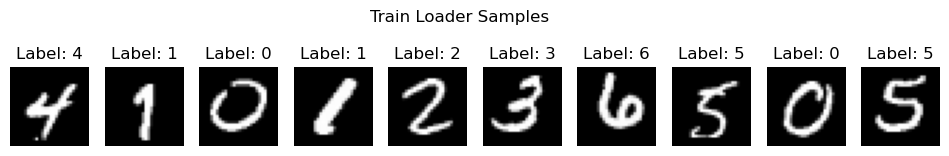

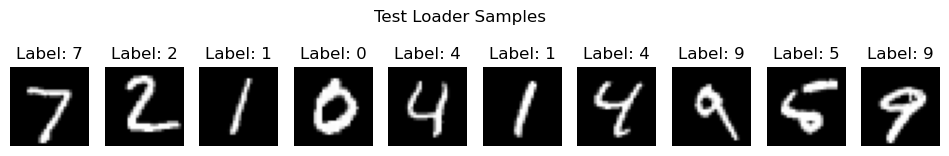

In [15]:
show_images_from_loader(train_loader, title="Train Loader Samples")
show_images_from_loader(test_loader, title="Test Loader Samples")

<div style="border: 1px solid #ccc; padding: 10px; border-radius: 8px;">
  <h3 style="margin-top:0;">8) 
  </h3>
  <p> Usually an anomaly detection algorithm is trained on normal data samples and then observing how it reacts on unseen, anomalous data. To do this, an anomaly detection approach is needed. 
      It is possible to use simple machine learning methods. Some examples would include Isolation Forest, k-NN, SVM, Decision Trees, Random Forest and many others.
      For the MNIST dataset however, a more complex approach might be needed as there are complex patterns in the way digits are formed (atleast for machines). An autoencoder would probably work as it utilizes neural networks and those can generally solve more complex problems than simpler machine learning methods as mentioned before. The autoencoder has two major components, the encoder and the decoder. 
      The encoder works by compressing data into a lower-dimensional latent space. This saves the most essential parts of a data sample. Then this latent space works as the input for the decoder whose purpose it is to recreate the original data sample. The training of the decoder works by mimizing the difference the original image and the recreated image.
      For the MNIST dataset, the autoencoder learns patterns in the digits it has learned from but struggles really hard to recreate images of unseen data. So by having an autoencoder that works well on digits 0-8, it will produce a badly reconstructed image of the unseen digit 9. So by observing the score function, one can eaisly spot when the algorithm is detecting an anomaly.</p>
</div>

<div style="border: 1px solid #ccc; padding: 10px; border-radius: 8px;">
  <h3 style="margin-top:0;">PART II. DIAGNOSIS
  </h3>
  <p> </p>
</div>

<div style="border: 1px solid #ccc; padding: 10px; border-radius: 8px;">
  <h3 style="margin-top:0;"> Discerning the classes
  </h3>
  <p>0	-Circular shape, closed loop, symmetric
<p>1	-Straight vertical line
<p>2	-Curved top, diagonal stroke from top right to lower left, horizontal base
<p>3	-Two stacked curves, no closed loops
<p>4	-Vertical + horizontal + diagonal line, sharp angles
<p>5	-Curved bottom, flat top
<p>6	-Closed loop on bottom, open top, like a reversed 9
<p>7	-Horizontal + diagonal stroke, no curves
<p>8	-Two stacked loops, symmetric, resembles "snowman"</p>
</div>

<div style="border: 1px solid #ccc; padding: 10px; border-radius: 8px;">
  <h3 style="margin-top:0;">PART III. PROGNOSIS
  </h3>
  <p> </p>
</div>

In [16]:
#Here I define column names (based on NASA documentation)
column_names = ['unit', 'time', 'operational_setting_1', 'operational_setting_2', 'operational_setting_3'] + \
               [f'sensor_{i}' for i in range(1, 22)]

#Loading the data
data = pd.read_csv("CMAPSS/train_FD001.txt", sep=' ', header=None)
data.dropna(axis=1, inplace=True)  # Drop empty columns
#data.columns = column_names

# Preview
print(data.head())


   0   1       2       3      4       5       6        7        8      9   \
0   1   1 -0.0007 -0.0004  100.0  518.67  641.82  1589.70  1400.60  14.62   
1   1   2  0.0019 -0.0003  100.0  518.67  642.15  1591.82  1403.14  14.62   
2   1   3 -0.0043  0.0003  100.0  518.67  642.35  1587.99  1404.20  14.62   
3   1   4  0.0007  0.0000  100.0  518.67  642.35  1582.79  1401.87  14.62   
4   1   5 -0.0019 -0.0002  100.0  518.67  642.37  1582.85  1406.22  14.62   

   ...      16       17       18      19    20   21    22     23     24  \
0  ...  521.66  2388.02  8138.62  8.4195  0.03  392  2388  100.0  39.06   
1  ...  522.28  2388.07  8131.49  8.4318  0.03  392  2388  100.0  39.00   
2  ...  522.42  2388.03  8133.23  8.4178  0.03  390  2388  100.0  38.95   
3  ...  522.86  2388.08  8133.83  8.3682  0.03  392  2388  100.0  38.88   
4  ...  522.19  2388.04  8133.80  8.4294  0.03  393  2388  100.0  38.90   

        25  
0  23.4190  
1  23.4236  
2  23.3442  
3  23.3739  
4  23.4044  

[5 rows

<div style="border: 1px solid #ccc; padding: 10px; border-radius: 8px;">
  <h3 style="margin-top:0;">Description of the C-MAPPS dataset
  </h3>
  <p> C-MAPSS simulates how turbofan jet engines degrade over time under various operating conditions. It uses high-fidelity models to produce realistic sensor readings as engines approach failure.
</p>     Each sub-dataset includes:
</p>train_FD00x.txt – Engine run-to-failure sequences (for training)
</p>test_FD00x.txt – Partial sequences (for predicting how long until failure)
</p>RUL_FD00x.txt – Ground-truth Remaining Useful Life (for each engine in test set)
</p>    Each row represents a time step of an engine and contains:
</p>-Engine ID
</p>-Time step
</p>-Engine Configuration
</p>-And finally 21 different sensor readings
</div>